# **UTN Santa Fe - Ciencia de Datos**
## *TP N°1 - Parte 2: Preprocesamiento de datos y entrenamiento*

---
### **Librerías**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler

---
### **Carga del conjunto de datos**
Realizamos la lectura del archivo `i40 (datos).csv` y visualizamos las primeras filas para comprobar que haya cargado correctamente.

In [2]:
# Leemos el archivo y visualizamos los primeros registros
df = pd.read_csv('i40 (datos).csv')
df.columns = df.columns.str.strip()
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


In [3]:
# Borramos los campos que no son necesarios para el modelo
df.drop('idx',axis=1, inplace=True)
df.drop('parent_device_id',axis=1, inplace=True)

df.head()

,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,L,303.80,313.30,1406,52.10,166,normal
1,L,302.30,311.20,1633,36.40,114,normal
2,M,302.27,311.47,1228,68.75,187,failure
3,L,302.35,311.93,1522,36.99,214,failure
4,L,296.70,307.90,1743,27.90,55,normal


---
### **Detección y tratamiento de datos faltantes**

Verificamos si existen datos faltantes:

In [4]:
valores_faltantes = df.isnull().sum()
print(valores_faltantes[valores_faltantes > 0])

air_temp [K]    40
dtype: int64


Notamos que faltan 40 valores en la columna `air_temp [K]` y los rellenamos con la mediana:

In [5]:
mediana = df['air_temp [K]'].median()
df['air_temp [K]'] = df['air_temp [K]'].fillna(mediana)

valores_faltantes = df.isnull().sum()
print(valores_faltantes[valores_faltantes > 0])

Series([], dtype: int64)


---
### **Detección y tratamiento de valores atípicos**
Visualizamos los valores atípicos de las variables numéricas mediante boxplots:

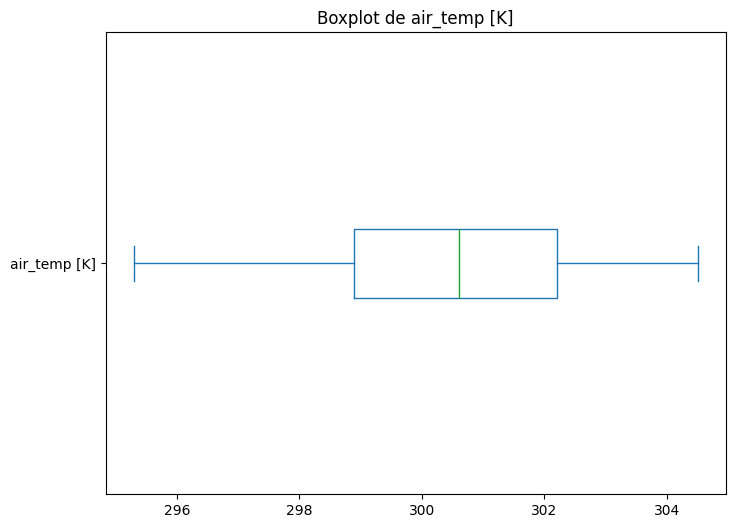

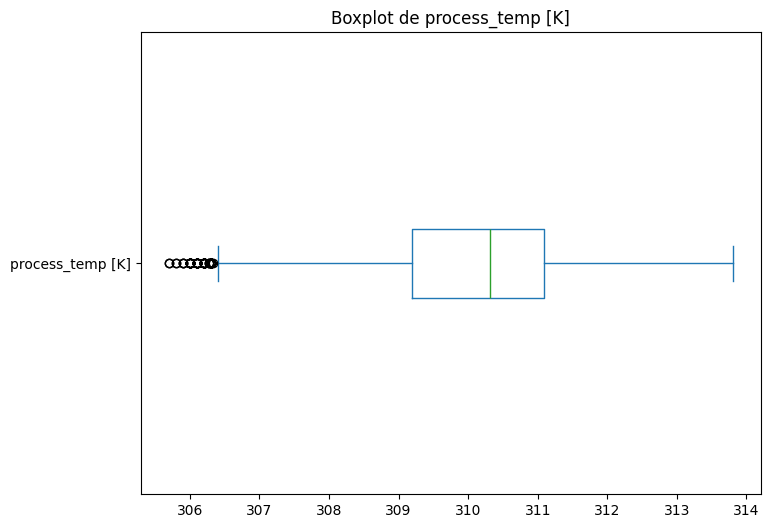

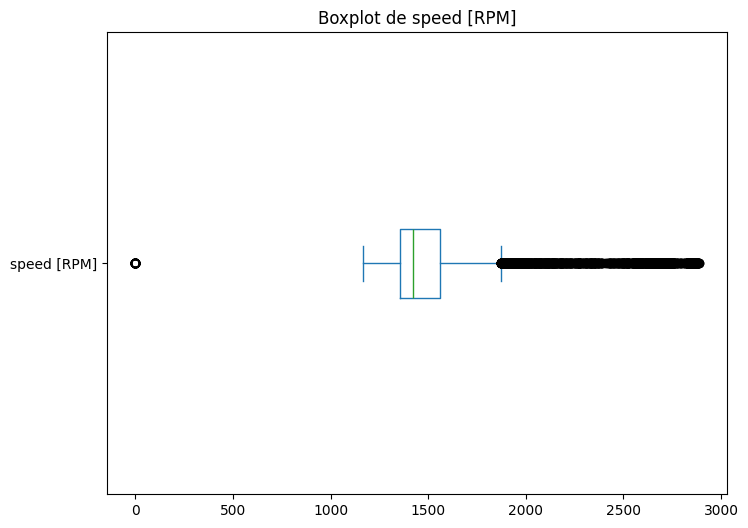

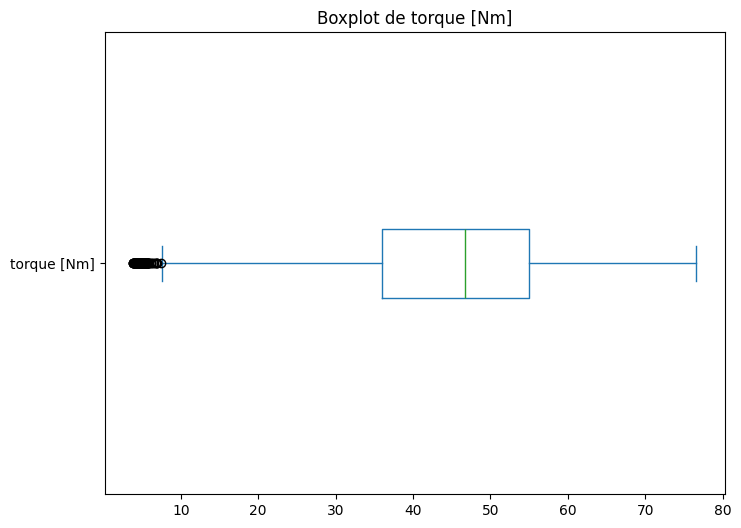

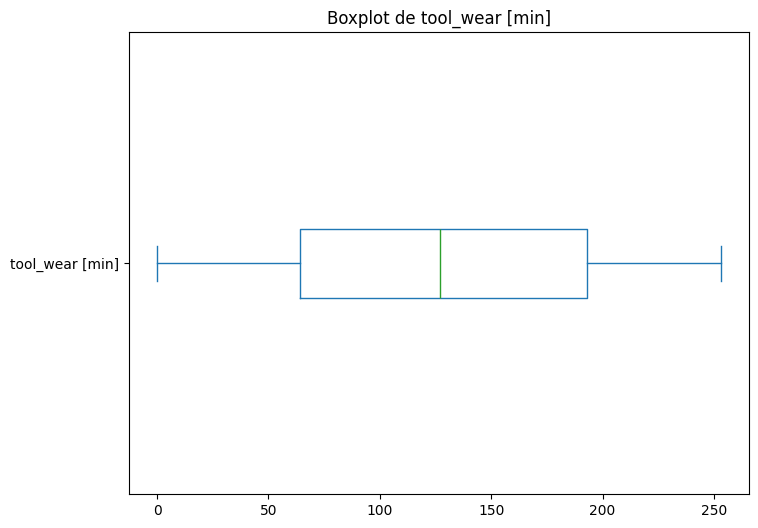

In [6]:
for columna in df.columns:
    if pd.api.types.is_numeric_dtype(df[columna]):
        plt.figure(figsize=(8, 6))
        df[columna].plot(kind='box', vert=False)
        plt.title(f"Boxplot de {columna}") 
        plt.show()

Notamos que las columnas de `process_temp [K]`, `speed [RPM]` y `torque [Nm]` presentan valores atípicos. Analizaremos la naturaleza de estos extremos antes de modificarlos. 

Comenzaremos buscando y corrigiendo mediante imputación únicamente los errores de sensor confirmados (como velocidades negativas). Luego, cruzaremos los valores atípicos restantes con la variable objetivo (target) para evaluar si estos representan eventos críticos vinculados a las fallas de la maquinaria.

Se encontraron 47 registros con velocidad (speed) negativa.
-> Estos valores fueron imputados con la mediana, asumiendo error del sensor.

--- Análisis de outliers vs. target (eventos críticos) ---
Evaluamos si los valores extremos coinciden con las fallas de la maquinaria.

Variable: process_temp [K]
  - Cantidad de outliers: 67
  - Probabilidad falla rango normal: 51.72%
  - Probabilidad falla OUTLIERS:     8.96%
------------------------------------------------------------
Variable: speed [RPM]
  - Cantidad de outliers: 1143
  - Probabilidad falla rango normal: 49.99%
  - Probabilidad falla OUTLIERS:     69.47%
------------------------------------------------------------
Variable: torque [Nm]
  - Cantidad de outliers: 107
  - Probabilidad falla rango normal: 51.17%
  - Probabilidad falla OUTLIERS:     100.00%
------------------------------------------------------------


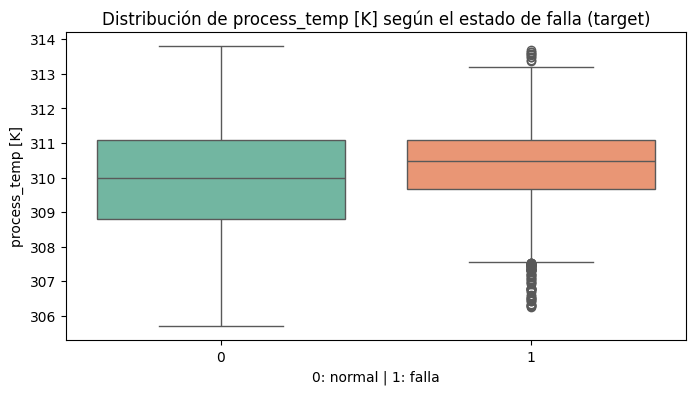

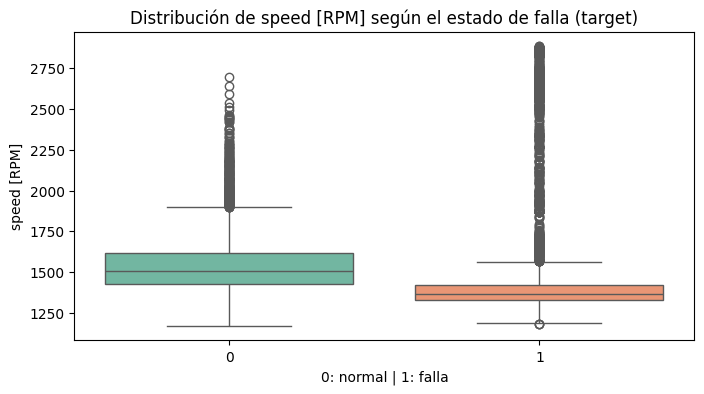

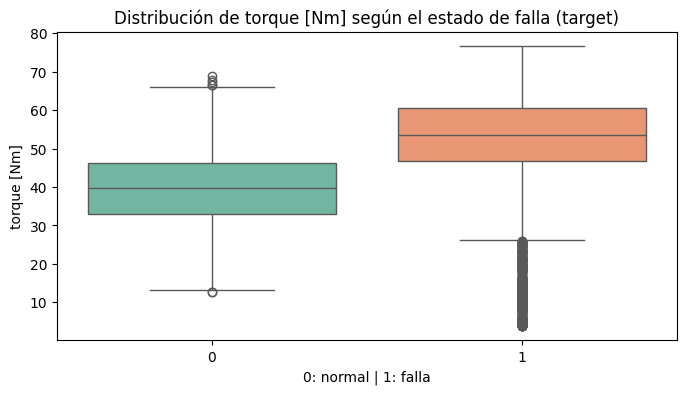

In [7]:
columnas = ['process_temp [K]', 'speed [RPM]', 'torque [Nm]']

# 1. Tratamiento de errores de sensor
# Buscamos velocidades negativas (físicamente imposible)
errores_speed = df['speed [RPM]'] < 0
cantidad_errores = errores_speed.sum()

print(f"Se encontraron {cantidad_errores} registros con velocidad (speed) negativa.")

if cantidad_errores > 0:
    # Imputamos los errores confirmados con la mediana de los datos válidos
    mediana_speed_real = df.loc[~errores_speed, 'speed [RPM]'].median()
    df.loc[errores_speed, 'speed [RPM]'] = mediana_speed_real
    print("-> Estos valores fueron imputados con la mediana, asumiendo error del sensor.")

# 2. Análisis de outliers como eventos críticos (fallas)
print("\n--- Análisis de outliers vs. target (eventos críticos) ---")
print("Evaluamos si los valores extremos coinciden con las fallas de la maquinaria.\n")

# Convertir target a valores binarios (0: normal, 1: falla)
if not pd.api.types.is_numeric_dtype(df['target']):
    df['target'] = df['target'].map({'normal': 0, 'failure': 1})

for col in columnas:
    # Calculamos límites estadísticos (IQR)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    bajo = q1 - 1.5 * iqr
    alto = q3 + 1.5 * iqr
    
    # Identificamos qué filas son outliers estadísticos para esta columna
    es_outlier = (df[col] < bajo) | (df[col] > alto)
    cantidad_outliers = es_outlier.sum()
    
    if cantidad_outliers > 0:
        # Calculamos qué porcentaje de esos outliers resultaron en falla (target == 1)
        tasa_falla_normal = df.loc[~es_outlier, 'target'].mean() * 100
        tasa_falla_outlier = df.loc[es_outlier, 'target'].mean() * 100
        
        print(f"Variable: {col}")
        print(f"  - Cantidad de outliers: {cantidad_outliers}")
        print(f"  - Probabilidad falla rango normal: {tasa_falla_normal:.2f}%")
        print(f"  - Probabilidad falla OUTLIERS:     {tasa_falla_outlier:.2f}%")
        print("-" * 60)

# 3. Visualización
for col in columnas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='target', y=col, hue='target', palette='Set2', legend=False)
    plt.title(f"Distribución de {col} según el estado de falla (target)")
    plt.xlabel("0: normal | 1: falla")
    plt.show()

Decidimos no imputar los outliers restantes porque el análisis demostró que son señales predictivas fundamentales. Especialmente en el caso de `torque [Nm]`, detectamos que el 100% de los valores atípicos resultan en falla, lo que convierte a esta variable en un predictor absoluto en rangos extremos. Asimismo, las variaciones drásticas en la probabilidad de falla para `speed [RPM]` (sube al 69%) y `process_temp [K]` (baja al 9%) demuestran que eliminar estos datos destruiría los patrones más importantes que el modelo debe aprender.

---
### **Correlación entre variables**
Calculamos las correlaciones de las columnas numéricas según un umbral de 0.90:


No se encontraron variables para eliminar con el umbral establecido.


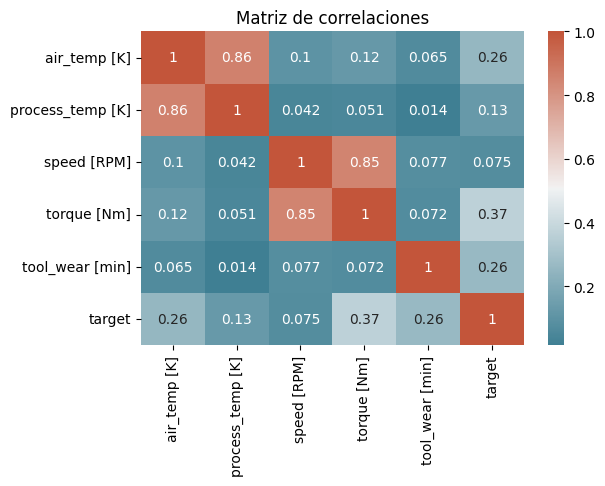

In [8]:
# Calculamos la matriz de correlación absoluta
corr = df.corr(numeric_only=True).abs()

# Calculamos un vector con las medias de cada columna
column_mean = corr.mean(axis=1)

# Visualizamos la matriz de correlación
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.tight_layout()
plt.title("Matriz de correlaciones")

columnas_a_eliminar = set()

# Calculo de las correlaciones de las columnas dado el umbral
umbral = .90
df_numbers = df[['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']]

for i in range(0, len(df_numbers.columns)):
    for j in range(i, len(df_numbers.columns)):
        if i != j:
            col_i = df_numbers.columns[i]
            col_j = df_numbers.columns[j]
            is_corr = np.abs(df_numbers[col_i].corr(df_numbers[col_j]))
            
            if is_corr > umbral:
                print(f"La variable {col_i} está altamente correlacionada con {col_j}")
                
                # Se elimina la variable con mayor promedio de correlación
                if column_mean[col_i] > column_mean[col_j]:
                    columnas_a_eliminar.add(col_i)
                else:
                    columnas_a_eliminar.add(col_j)

# Eliminación de variables
if columnas_a_eliminar:
    print(f"\nEliminando columnas por alta redundancia: {columnas_a_eliminar}")
    df.drop(columns=list(columnas_a_eliminar), inplace=True)
else:
    print("\nNo se encontraron variables para eliminar con el umbral establecido.")

---
### **Procesamiento de variables categóricas**
En este caso sólo tenemos variables categóricas nominales (`product_type` y `target`). Para este tipo de variables categóricas se pretende evitar una ponderación que pueda sesgar el conjunto de datos, por lo que utilizaremos una codificación one-hot para la variable `product_type` pero no para la variable `target`, dado que la misma es binaria.

In [9]:
# Variable objetivo 'target': ya fue mapeada a valores binarios para el estudio y tratamiento de outliers
# 0: estado normal, 1: falla

# Variable nominal 'product_type': aplicamos codificación one-hot
df = pd.get_dummies(df, columns=['product_type'], dtype=int)

df.head()

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target,product_type_H,product_type_L,product_type_M
0,303.80,313.30,1406,52.10,166,0,0,1,0
1,302.30,311.20,1633,36.40,114,0,0,1,0
2,302.27,311.47,1228,68.75,187,1,0,0,1
3,302.35,311.93,1522,36.99,214,1,0,1,0
4,296.70,307.90,1743,27.90,55,0,0,1,0


---
### **Balance del conjunto de datos**
Para solucionar el desbalance del conjunto de datos utilizaremos la técnica de over-sampling, la cual se trata de aumentar la cantidad de muestras de la clase minoritaria para alcanzar a la más abundante. 

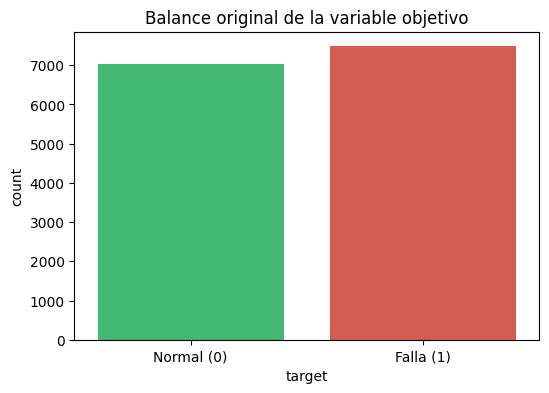

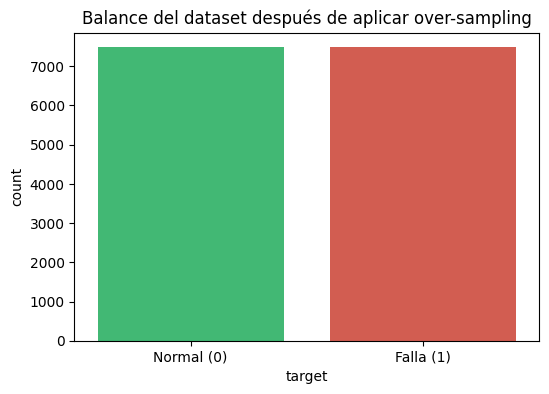

In [10]:
# Separamos el dataset en entradas (X) y salida esperada (y)
X = df.drop('target', axis=1)
y = df['target']

# Visualizamos el balance del dataset original
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title("Balance original de la variable objetivo")
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Falla (1)'])
plt.show()

# Generamos un nuevo conjunto de datos balanceado por over-sampling
from imblearn.over_sampling import RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority')

# Generamos el nuevo dataset balanceado
X_over, y_over = oversample.fit_resample(X, y)

# Visualización del balance del dataset generado
plt.figure(figsize=(6, 4))
sns.countplot(x=y_over, hue=y_over, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title("Balance del dataset después de aplicar over-sampling")
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Falla (1)'])
plt.show()

---
### **Normalización del conjunto de datos**

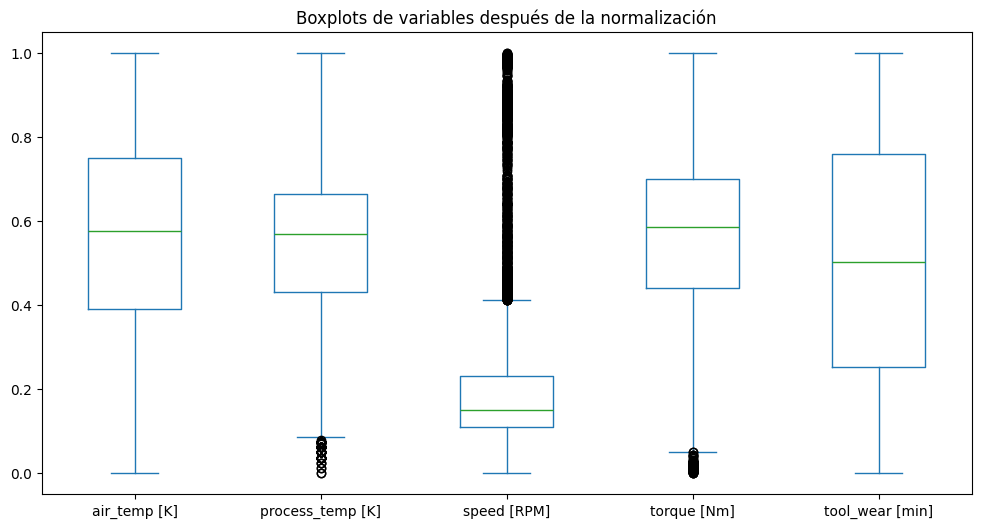

In [11]:
# Copiar las variables
X_normal = X_over.copy()
  
# Aplicamos normalización manual a las columnas numéricas (excluimos las categóricas codificadas)
columns = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

for column in columns:
    X_normal[column] = (X_normal[column] - X_normal[column].min()) / (X_normal[column].max() - X_normal[column].min())    

# Visualizamos la distribución de las distintas variables normalizadas
fig, ax = plt.subplots(figsize=(12, 6))
X_normal.loc[:, columns].plot(kind='box', ax=ax)
plt.title("Boxplots de variables después de la normalización")
plt.show()